# Response-rate sensitivity analyses

Author: Tien Tyler Le 

Date: 07/08/2026



Two evidence artifacts for the synthetic generator + decision methods, built on the MSSD-based JITAI
decision engine in `syntheticData/decision/`:

TLDR:

- High response rate good. Recovers both volatility ($\sigma$) and autocorrelation ($\rho$) better. 
- $\rho$ is more sensitive to response rate
- MSSD recovery improves as response rate goes up.
    - Because we can understand a participant's volatility and autocorrelation better. Hence, our threshold is less noisy, bringing more precision. 
    - Accuracy is only determine if we mirror the participant's actual underlying behavioral state (user feedback), which can be helped with data completeness. 

Hence, aiming for >70% response rate from participants is ideal. 

# Problem Statement

Parameter Recovery suggests that Response rate may have an effect on $\rho$ and $\sigma$ recovery. However, we do not know if it is a causation or correlation from another factors, such as the prompt thresholds, or number of EMA observations.

In [16]:
import os
import sys
from IPython.display import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import Image

%matplotlib inline

# Resolve sibling modules the same way run_decision_engine.py / mssd_validation.py do.
HERE = os.getcwd()
PARENT = os.path.dirname(HERE)
for p in (HERE, PARENT):
    if p not in sys.path:
        sys.path.insert(0, p)

from synthetic_generator import generate_cohort
from decision_engine import calculate_mssd, apply_decision_rules
from mssd_validation import recover_ar1_params, empirical_mssd
from run_decision_engine import spread_ema_timestamps

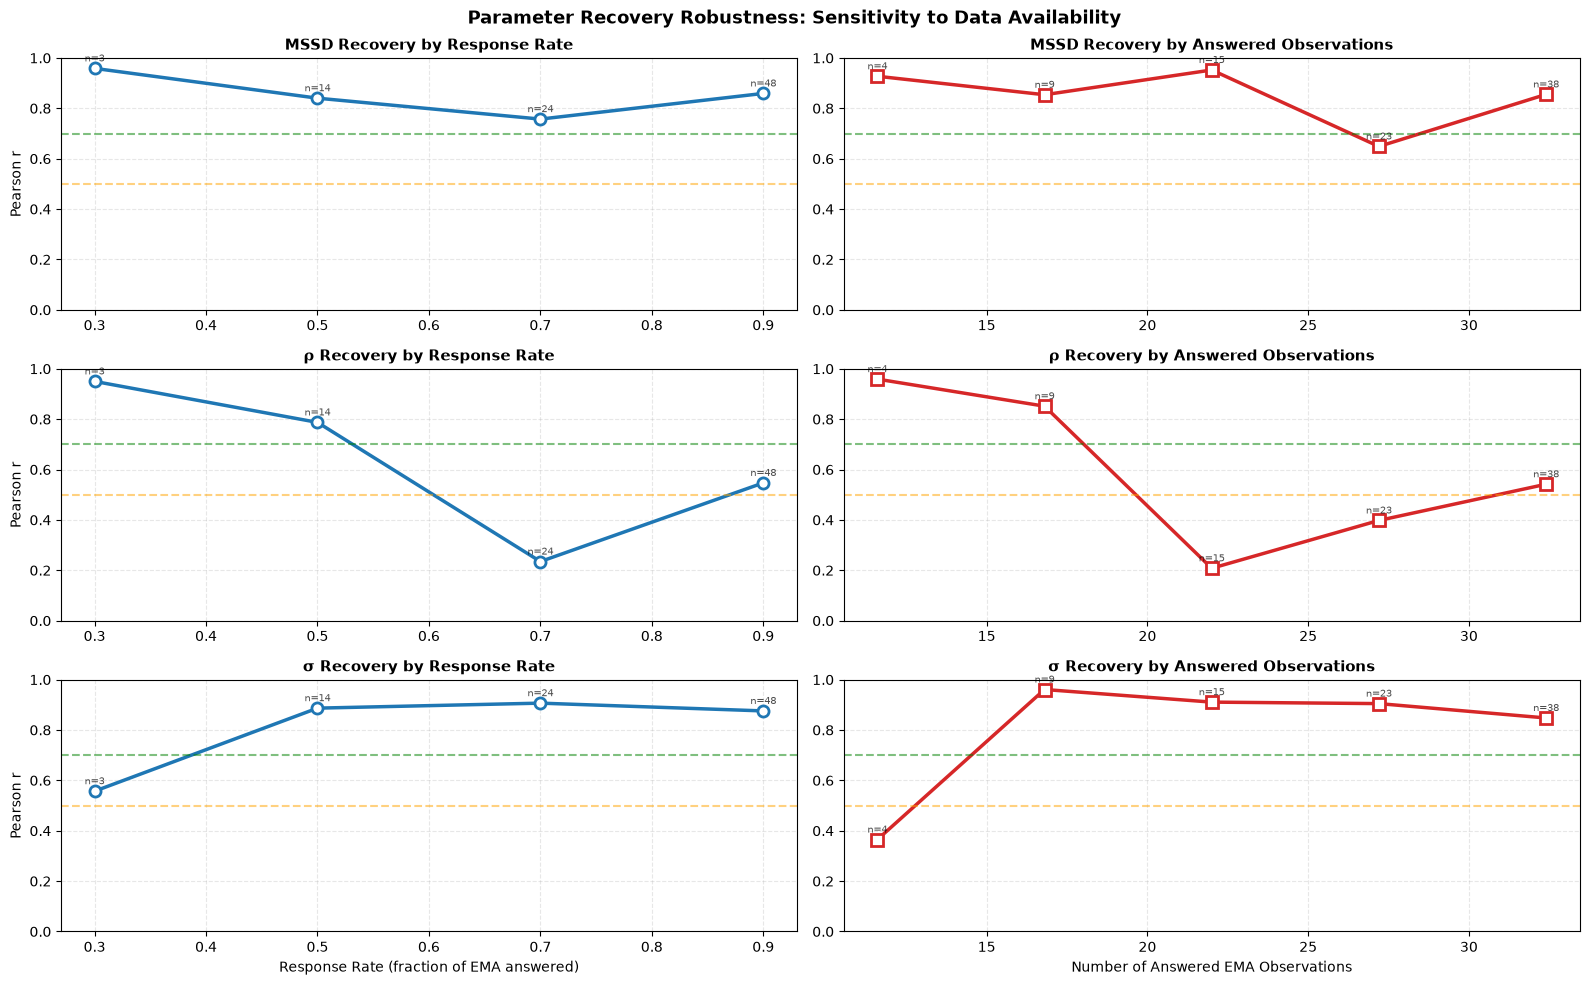

In [17]:
Image(filename='./figures/recovery_by_data_availability.png', width=1000)

# Sensitivity Analysis

1. **Threshold sensitivity grid** 
   - Response rate tested: *70–90%*
   - Burn-in length: how long to collect data before triggering intervention prompts per participant per week
   - Characterizes the JITAI dosage a study would deliver under different
   compliance and warm-up assumptions.

2. **Recovery question** | does response rate significantly affect recovery of
   - the latent AR(1) parameters (ρ, σ) and the MSSD signal? 
   - response-rate sweep plus regression / ANOVA.



In [18]:
FIGURE_DIR = os.path.join(HERE, "figures")
OUTPUT_DIR = os.path.join(HERE, "outputs")
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# same decision rule as the decision engine
THRESHOLD_QUANTILE = 0.80
COOLDOWN_MINUTES = 60
MAX_PROMPTS_PER_DAY = 4
MSSD_WINDOW = 3
SEED = 42
print("setup ok")

setup ok


## Threshold sensitivity grid

For each response-rate row we generate one cohort (latent σ/ρ/μ random, but the
**same** population across response rates via a fixed seed), run the decision
engine once, then read off each burn-in column by counting `send_prompt` events
**after** the warm-up window. During the burn-in the MSSD/threshold history still
accrues, but prompts fired there are not
counted. Counts are normalized to a 7-day week over the retained window
`(DAYS - burn_in_days)`. Holding the population fixed keeps each axis attributable
to the factor it manipulates (compliance vs. warm-up), not to resampling noise.

### pseudo

For each response-rate (70-90%):
- we generate one cohort w/ random σ/ρ/μ and a given warm-up window.
- same population across response rates w/ fixed seed.
- MSSD/threshold still gets recorded
- The decision threshold triggers after the warm-up window.


### variables tested 

Independents:
- MSSD
- Recovered $\rho$ / $\sigma$

Dependents:
- Response-rate
- Warm-up window (burn-ins)
- Sampling size
- Prompt Thresholds

In [19]:
def build_prompt_dosage_grid(resp_rates, burn_in_days_list,
                             users=100, days=28, ema_per_day=5, seed=SEED):
    """Return a tidy DataFrame: one row per (resp_rate, burn_in_days) cell with
    the mean triggered-intervention prompts per participant per week.

    Design for a clean sensitivity figure: the latent AR(1) series is drawn
    BEFORE the missingness mask in generate_user, so passing the same `seed`
    across response rates holds the underlying population (sigma/rho/mu and the
    latent path) fixed -- only which prompts are answered changes. And because
    burn-in only affects *which* prompts we count (history still accrues through
    the warm-up), the decision engine is run once per response rate and then
    sliced across every burn_in column. That isolates each axis to the factor it
    manipulates instead of resampling a fresh population per cell.
    """
    records = []
    for rr in resp_rates:
        cohort = generate_cohort(users=users, days=days, ema_per_day=ema_per_day,
                                 seed=seed, resp_rate=rr)
        cohort = spread_ema_timestamps(cohort, ema_per_day)
        dec = calculate_mssd(cohort, window=MSSD_WINDOW)
        dec = apply_decision_rules(dec,
                                   threshold_quantile=THRESHOLD_QUANTILE,
                                   cooldown_minutes=COOLDOWN_MINUTES,
                                   max_prompts_per_day=MAX_PROMPTS_PER_DAY)
        for bd in burn_in_days_list:
            weeks = (days - bd) / 7.0
            post = dec[dec["day"] >= bd]
            per_user = post.groupby("user_id")["send_prompt"].sum() / weeks
            records.append({
                "resp_rate": rr,
                "burn_in_days": bd,
                "prompts_per_week": float(per_user.mean()),
            })
    return pd.DataFrame(records)

In [28]:
RESP_RATES = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
BURN_IN_DAYS = [0, 1, 2, 3, 5, 7]
USERS_A, DAYS_A, EMA_PER_DAY = 100, 28, 5

grid_df = build_prompt_dosage_grid(RESP_RATES, BURN_IN_DAYS,
                                   users=USERS_A, days=DAYS_A, ema_per_day=EMA_PER_DAY)
grid_df.to_csv(os.path.join(OUTPUT_DIR, "threshold_sensitivity_grid.csv"), index=False)

grid_mat = grid_df.pivot(index="resp_rate", columns="burn_in_days",
                         values="prompts_per_week")
print("grid shape:", grid_mat.shape,
      "| all finite & >= 0:",
      bool(np.isfinite(grid_mat.to_numpy()).all() and (grid_mat.to_numpy() >= 0).all()))
grid_mat.round(2)

grid shape: (8, 6) | all finite & >= 0: True


burn_in_days,0,1,2,3,5,7
resp_rate,,,,,,
0.60,4.75,4.67,4.31,4.48,3.96,4.00
0.65,8.25,8.56,8.88,8.96,9.13,8.00
0.70,5.00,5.19,4.58,4.48,4.87,5.33
0.75,2.00,2.07,2.15,2.24,1.83,2.00
0.80,6.00,6.22,6.46,6.72,7.30,7.33
0.85,3.00,3.11,3.23,3.36,3.65,4.00
0.90,4.25,4.41,4.58,4.20,4.57,4.00
0.95,3.50,3.63,3.77,3.92,3.65,3.67


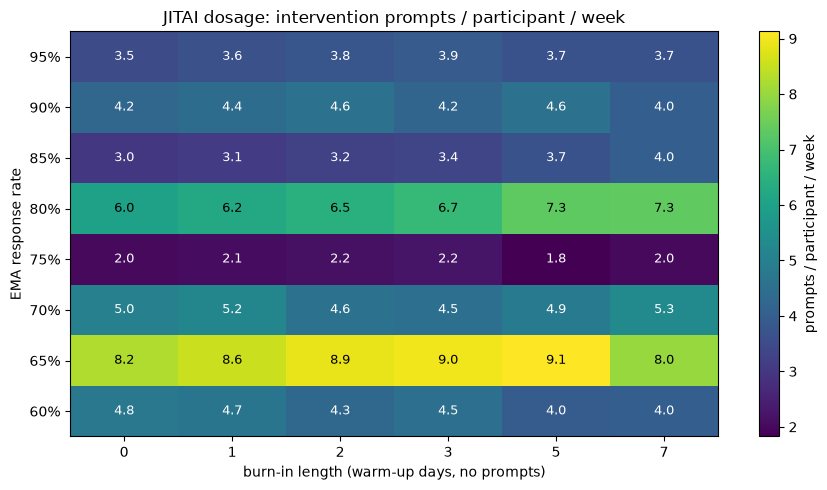

In [29]:
mat = grid_mat.to_numpy()
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(mat, aspect="auto", origin="lower", cmap="viridis")

ax.set_xticks(range(grid_mat.shape[1]))
ax.set_xticklabels(grid_mat.columns)
ax.set_yticks(range(grid_mat.shape[0]))
ax.set_yticklabels([f"{r:.0%}" for r in grid_mat.index])
ax.set_xlabel("burn-in length (warm-up days, no prompts)")
ax.set_ylabel("EMA response rate")
ax.set_title("JITAI dosage: intervention prompts / participant / week")

thresh = np.nanmax(mat) * 0.6
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i, j]:.1f}", ha="center", va="center", fontsize=9,
                color="white" if mat[i, j] < thresh else "black")

fig.colorbar(im, ax=ax, label="prompts / participant / week")
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "threshold_sensitivity_grid.png"),
            bbox_inches="tight")
plt.show()

### INTERPRETATION OF THIS GRID

This grid visualizes the effects of EMA response rate and warm-up days before sending intervention prompts. 

- A longer warm-up period is meant to be a stabilizing filter, or reduces the **Cold-start Problem**. MSSD of a given user has no baseline, or lack calibration on our end, so by extending the burn-in length, the MSSD threshold trims out the noise a bit better. Ideally, this helps prevents over-trigger prompts early on. 

- As the response rate increases, the decision engine receives a higher volume of answered EMAs. This richer data flow feeds directly into the within-person threshold calculations. Essentially, higher compliance allows the threshold to dynamically adjust to the specific user's baseline more accurately, rather than firing off incomplete or sparse data.


TLDR:
- longer days to warm up, less noise, less false positives and over-sending prompts
- more responses, less noisy Likert values, better baseline so better thresholds

----------------
## Response rate vs ρ/σ recovery and MSSD

Sweep response rate across levels, drawing a fresh population (random latent
σ/ρ) at each level, recover the AR(1) parameters and empirical MSSD per user,
then test whether recovery error and the MSSD <-> latent relationship depend on
response rate (linear regression across users + one-way ANOVA across levels).

We're trying to answer:

- **Does parameter recovery and MSSD really gets affected by MSSD?**

In [22]:
def run_recovery_sweep(resp_rates, users_per_level=200, days=14, ema_per_day=5, seed=SEED):
    """One row per user across all response-rate levels: true vs recovered
    (σ, ρ), empirical vs expected MSSD, and answered-count."""
    recs = []
    for k, rr in enumerate(resp_rates):
        cohort = generate_cohort(users=users_per_level, days=days,
                                 ema_per_day=ema_per_day, seed=seed + 1000 + k,
                                 resp_rate=rr)
        for uid, g in cohort.groupby("user_id"):
            g = g.sort_values("prompt_idx")
            ema = g["ema"].to_numpy()
            rho_hat, sigma_hat = recover_ar1_params(ema)
            recs.append({
                "resp_rate": rr,
                "user_id": uid,
                "true_sigma": float(g["true_sigma"].iloc[0]),
                "true_rho": float(g["true_rho"].iloc[0]),
                "true_expected_mssd": float(g["true_expected_mssd"].iloc[0]),
                "sigma_hat": sigma_hat,
                "rho_hat": rho_hat,
                "empirical_mssd": empirical_mssd(ema),
                "n_answered": int(np.sum(~np.isnan(ema))),
            })
    df = pd.DataFrame(recs)
    df["abs_err_sigma"] = (df["sigma_hat"] - df["true_sigma"]).abs()
    df["abs_err_rho"] = (df["rho_hat"] - df["true_rho"]).abs()
    df["signed_err_sigma"] = df["sigma_hat"] - df["true_sigma"]
    df["signed_err_rho"] = df["rho_hat"] - df["true_rho"]
    return df

In [23]:
SWEEP_RESP_RATES = np.round(np.arange(0.50, 0.96, 0.05), 2) # [0.50, 0.55, 0.60, 0.65,... 0.95]
USERS_PER_LEVEL, DAYS_B = 200, 14

sweep_df = run_recovery_sweep(SWEEP_RESP_RATES, users_per_level=USERS_PER_LEVEL,
                              days=DAYS_B, ema_per_day=EMA_PER_DAY)
print("sweep rows:", len(sweep_df),
      "| levels:", sweep_df['resp_rate'].nunique())
sweep_df.head()

sweep rows: 2000 | levels: 10


,resp_rate,user_id,true_sigma,true_rho,true_expected_mssd,sigma_hat,rho_hat,empirical_mssd,n_answered,abs_err_sigma,abs_err_rho,signed_err_sigma,signed_err_rho
0,0.5,00dd7db6-c612-417a-8a72-ae4200aaefea,0.364925,0.671425,0.087513,0.497350,0.495358,0.266667,44,0.132425,0.176068,0.132425,-0.176068
1,0.5,04932d31-62b0-48eb-8a94-440b7f347470,1.131350,0.691400,0.789987,1.051251,0.521236,1.160000,40,0.080099,0.170164,-0.080099,-0.170164
2,0.5,0b179aef-211d-43b5-8355-dcd4146e6086,0.742732,0.120886,0.969928,0.715172,0.190602,0.827586,39,0.027560,0.069716,-0.027560,0.069716
3,0.5,0bf67c85-6d38-498d-99f3-f2c947b0c7de,0.354615,0.530464,0.118090,0.404554,0.250179,0.200000,37,0.049938,0.280284,0.049938,-0.280284
4,0.5,0cc6b6e9-c83b-4b07-b342-7e1a308e7dc7,1.117150,0.383755,1.538177,0.967323,0.381409,1.130435,36,0.149826,0.002345,-0.149826,-0.002345


In [24]:
# --- Significance tests -------------------------------------------------
def ci95(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if x.size < 2:
        return np.nan
    return 1.96 * x.std(ddof=1) / np.sqrt(x.size)

# Per-level aggregates (mean abs err + 95% CI, and within-level MSSD Pearson r).
per_level_rows = []
for rr, grp in sweep_df.groupby("resp_rate"):
    sub = grp.dropna(subset=["empirical_mssd", "true_expected_mssd"])
    mssd_r = stats.pearsonr(sub["true_expected_mssd"], sub["empirical_mssd"])[0] \
        if len(sub) >= 3 else np.nan
    per_level_rows.append({
        "resp_rate": rr,
        "n": len(grp),
        "mean_abs_err_sigma": grp["abs_err_sigma"].mean(),
        "ci_abs_err_sigma": ci95(grp["abs_err_sigma"]),
        "mean_abs_err_rho": grp["abs_err_rho"].mean(),
        "ci_abs_err_rho": ci95(grp["abs_err_rho"]),
        "mssd_pearson_r": mssd_r,
    })
per_level = pd.DataFrame(per_level_rows).sort_values("resp_rate").reset_index(drop=True)

# Regression of per-user recovery error on response rate (across all users).
vs = sweep_df.dropna(subset=["abs_err_sigma"])
vr = sweep_df.dropna(subset=["abs_err_rho"])
reg_sigma = stats.linregress(vs["resp_rate"], vs["abs_err_sigma"])
reg_rho = stats.linregress(vr["resp_rate"], vr["abs_err_rho"])

# One-way ANOVA: does mean recovery error differ across response-rate levels?
grp_sigma = [g["abs_err_sigma"].dropna().to_numpy() for _, g in sweep_df.groupby("resp_rate")]
grp_rho = [g["abs_err_rho"].dropna().to_numpy() for _, g in sweep_df.groupby("resp_rate")]
anova_sigma = stats.f_oneway(*grp_sigma)
anova_rho = stats.f_oneway(*grp_rho)

# Does the MSSD<->latent relationship strengthen with response rate?
pl = per_level.dropna(subset=["mssd_pearson_r"])
reg_mssd_r = stats.linregress(pl["resp_rate"], pl["mssd_pearson_r"])

stats_block = pd.DataFrame([
    {"metric": "abs_err_sigma ~ resp_rate", "slope": reg_sigma.slope,
     "r_squared": reg_sigma.rvalue ** 2, "p_value": reg_sigma.pvalue,
     "anova_F": anova_sigma.statistic, "anova_p": anova_sigma.pvalue},
    {"metric": "abs_err_rho ~ resp_rate", "slope": reg_rho.slope,
     "r_squared": reg_rho.rvalue ** 2, "p_value": reg_rho.pvalue,
     "anova_F": anova_rho.statistic, "anova_p": anova_rho.pvalue},
    {"metric": "mssd_pearson_r ~ resp_rate", "slope": reg_mssd_r.slope,
     "r_squared": reg_mssd_r.rvalue ** 2, "p_value": reg_mssd_r.pvalue,
     "anova_F": np.nan, "anova_p": np.nan},
])

per_level.to_csv(os.path.join(OUTPUT_DIR, "recovery_vs_response_rate.csv"), index=False)
stats_block.to_csv(os.path.join(OUTPUT_DIR, "recovery_vs_response_rate_stats.csv"), index=False)

print(per_level.round(4).to_string(index=False))
print()
print(stats_block.round(5).to_string(index=False))

 resp_rate   n  mean_abs_err_sigma  ci_abs_err_sigma  mean_abs_err_rho  ci_abs_err_rho  mssd_pearson_r
      0.50 200              0.1149            0.0131            0.2112          0.0229          0.7982
      0.55 200              0.1247            0.0146            0.1878          0.0218          0.8817
      0.60 200              0.1192            0.0133            0.1607          0.0171          0.8755
      0.65 200              0.1210            0.0139            0.1626          0.0201          0.8857
      0.70 200              0.1164            0.0137            0.1655          0.0182          0.8819
      0.75 200              0.1208            0.0146            0.1576          0.0173          0.9134
      0.80 200              0.1090            0.0127            0.1496          0.0167          0.8979
      0.85 200              0.1145            0.0136            0.1386          0.0147          0.9213
      0.90 200              0.1170            0.0132            0.1336   

# ANOVA Interpretation

Given the change in response rate:

$|Error(Volatility)|$ : 
- Slope = -0.27 ; $\sigma$ error goes down as response rate goes up
- Anova P = 0.50 ; group averages of $\sigma$ at varying resp_rate are mostly different 
- p_val = 0.06792 ; There is a 6.8% probability that there is a difference, so it is not statisically significant

$|Error(Autocorrelation)|$ : 
- Slope = -0.27: Same as above, error down as response rate up
- Anova P and P-val : reject null hypothesis, that there is a statiscally significant difference with resp_rate for $\rho$
- Hence, high $\rho$ recovery needs a high response rate *aka compliance from participants*


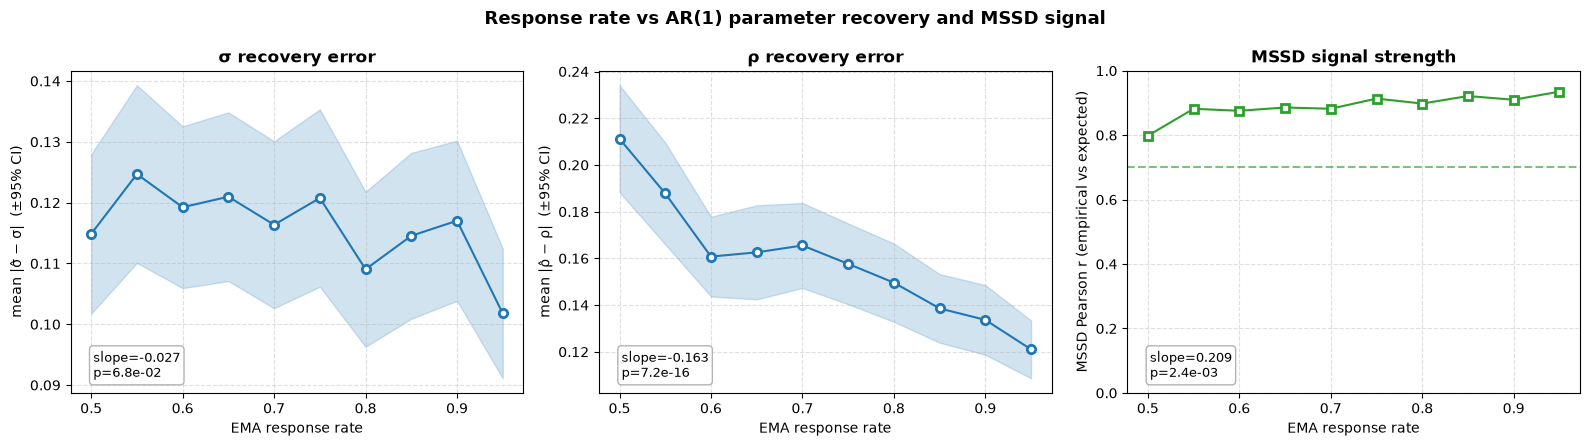

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

def err_panel(ax, mean_col, ci_col, reg, title, ylabel):
    x = per_level["resp_rate"].to_numpy()
    y = per_level[mean_col].to_numpy()
    ci = per_level[ci_col].to_numpy()
    ax.plot(x, y, "o-", color="tab:blue", markerfacecolor="white", markeredgewidth=2)
    ax.fill_between(x, y - ci, y + ci, alpha=0.2, color="tab:blue")
    ax.set_xlabel("EMA response rate")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.annotate(f"slope={reg.slope:.3f}\np={reg.pvalue:.1e}",
                xy=(0.05, 0.05), xycoords="axes fraction",
                bbox=dict(boxstyle="round", fc="white", ec="0.7"), fontsize=9)

err_panel(axes[0], "mean_abs_err_sigma", "ci_abs_err_sigma", reg_sigma,
          "σ recovery error", "mean |σ̂ − σ|  (±95% CI)")
err_panel(axes[1], "mean_abs_err_rho", "ci_abs_err_rho", reg_rho,
          "ρ recovery error", "mean |ρ̂ − ρ|  (±95% CI)")

x = per_level["resp_rate"].to_numpy()
axes[2].plot(x, per_level["mssd_pearson_r"].to_numpy(), "s-", color="tab:green",
             markerfacecolor="white", markeredgewidth=2)
axes[2].axhline(0.7, color="green", linestyle="--", alpha=0.5)
axes[2].set_ylim(0, 1)
axes[2].set_xlabel("EMA response rate")
axes[2].set_ylabel("MSSD Pearson r (empirical vs expected)")
axes[2].set_title("MSSD signal strength", fontweight="bold")
axes[2].grid(True, linestyle="--", alpha=0.4)
axes[2].annotate(f"slope={reg_mssd_r.slope:.3f}\np={reg_mssd_r.pvalue:.1e}",
                 xy=(0.05, 0.05), xycoords="axes fraction",
                 bbox=dict(boxstyle="round", fc="white", ec="0.7"), fontsize=9)

fig.suptitle("Response rate vs AR(1) parameter recovery and MSSD signal",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "recovery_vs_response_rate.png"),
            bbox_inches="tight")
plt.show()

## Findings

- **Part A** (`threshold_sensitivity_grid.png`): the grid shows how the
  intervention dosage (prompts / participant / week) moves with EMA response
  rate and burn-in length. Longer burn-in trims the early, high-MSSD prompts
  
    - Higher response rate feeds more answered EMAs into the within-person threshold.

- **Part B** (`recovery_vs_response_rate.csv`):

  - The response rate does not have a mathematically proven impact on the accuracy of recovering the true $\sigma$ in this specific test. The error rate remains relatively stable regardless of compliance.
  - Unlike $\sigma$, accurately capturing $\rho$ relies heavily on having a high response rate. If a participant skips too many prompts, our ability to estimate how their current mood/behavior carries over into the future ($\rho$) degrades significantly.
  - MSSD is only a reliable proxy when the user actually responds to EMAs, **so we need to aim for > 70% response rate from participants**.